# Florence Airbnb – Data Cleaning and Feature Engeneering Notebook

This notebook documents the **data preparation pipeline** for an Airbnb listings dataset from Florence.

The goals are to:
- Load the raw listings data and inspect its structure
- Clean and standardise key variables (IDs, location, capacity, prices, reviews)
- Handle missing values and inconsistent types
- Derive additional features (including selected amenity indicators)
- Produce a modeling‑ready dataset for later analysis and prediction tasks

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
import re
import ast
import json
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

## Load raw data

In [2]:
listings = pd.read_csv('data/listings.csv')

## Select relevant columns

Only the variables needed for cleaning and later modeling are kept.  
This reduces the dataset to a focused set of listing, review, neighbourhood, and amenity features.

In [3]:
columns = ['id',
       'description', 'neighborhood_overview', 'neighbourhood',
       'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value']
listings = listings[columns].copy()

## Initial overview

The dataset is inspected with structural and descriptive summaries.  
This gives a first view of column types, typical values, and the general shape of the data.

In [4]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13266 entries, 0 to 13265
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           13266 non-null  int64  
 1   description                  12920 non-null  object 
 2   neighborhood_overview        6835 non-null   object 
 3   neighbourhood                6835 non-null   object 
 4   neighbourhood_cleansed       13266 non-null  object 
 5   latitude                     13266 non-null  float64
 6   longitude                    13266 non-null  float64
 7   property_type                13266 non-null  object 
 8   room_type                    13266 non-null  object 
 9   accommodates                 13266 non-null  int64  
 10  bathrooms                    12107 non-null  float64
 11  bathrooms_text               13260 non-null  object 
 12  bedrooms                     13118 non-null  float64
 13  beds            

In [5]:
listings.describe()

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,1.326600e+04,13266.000000,13266.000000,13266.000000,12107.000000,13118.000000,12078.000000,13266.000000,13266.000000,13266.000000,11845.000000,11845.000000,11845.000000,11845.000000,11845.000000,11845.000000,11845.000000
mean,6.606324e+17,43.774209,11.253247,3.876602,1.356984,1.552752,2.230999,5.019147,366.747852,75.965099,4.748690,4.796606,4.782044,4.828534,4.842594,4.818798,4.684516
std,5.760922e+17,0.009556,0.016667,1.957733,0.702807,0.885751,1.438408,16.602583,411.198265,116.746036,0.351196,0.319690,0.332723,0.291141,0.288984,0.262574,0.365624
min,3.184000e+04,43.727430,11.157921,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.211481e+07,43.768730,11.244976,2.000000,1.000000,1.000000,1.000000,1.000000,29.000000,5.000000,4.670000,4.750000,4.720000,4.790000,4.810000,4.750000,4.600000
50%,8.118701e+17,43.772670,11.253967,4.000000,1.000000,1.000000,2.000000,2.000000,365.000000,29.000000,4.840000,4.880000,4.880000,4.910000,4.930000,4.900000,4.770000
75%,1.189059e+18,43.778447,11.261600,5.000000,2.000000,2.000000,3.000000,3.000000,365.000000,94.000000,4.950000,4.970000,4.970000,4.980000,5.000000,4.980000,4.890000
max,1.514605e+18,43.830430,11.336280,16.000000,13.500000,13.000000,17.000000,600.000000,3000.000000,1196.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [6]:
listings.head()

,id,description,neighborhood_overview,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,31840,"Nice, private and quiet double room, classic s...",NaN,NaN,Centro Storico,43.77709,11.25216,Private room in serviced apartment,Private room,2,...,1,99,174,4.67,4.74,4.84,4.86,4.90,4.88,4.67
1,32180,.,NaN,NaN,Centro Storico,43.76832,11.24348,Entire condo,Entire home/apt,4,...,6,31,42,4.76,4.82,4.82,4.79,4.72,4.82,4.85
2,39115,"Double Room Shared Bathroom: comfortable, larg...","San Lorenzo Church, the market and Cappelle Me...","Florence, Tuscany, Italy",Centro Storico,43.77525,11.25258,Private room in home,Private room,2,...,2,35,88,4.52,4.70,4.61,4.80,4.74,4.91,4.55
3,39165,"Double room private bathroom: comfortable, lar...","San Lorenzo Church, the market and Cappelle Me...","Florence, Tuscany, Italy",Centro Storico,43.77525,11.25258,Private room in home,Private room,2,...,2,35,24,4.41,4.32,4.55,4.73,4.64,4.95,4.41
4,39822,Location details.<br />The bridge right next t...,NaN,NaN,Centro Storico,43.76742,11.24378,Entire rental unit,Entire home/apt,4,...,4,1124,37,4.50,4.44,4.50,4.71,4.74,4.88,4.53


## Missing values overview

The next step checks how missing values are distributed across columns.  
This helps identify which variables need explicit handling later in the notebook.

In [7]:
na_counts = listings.isna().sum().sort_values(ascending=False)
print(na_counts)

neighbourhood                  6431
neighborhood_overview          6431
review_scores_location         1421
review_scores_rating           1421
review_scores_cleanliness      1421
review_scores_accuracy         1421
review_scores_value            1421
review_scores_communication    1421
review_scores_checkin          1421
beds                           1188
price                          1173
bathrooms                      1159
description                     346
bedrooms                        148
bathrooms_text                    6
latitude                          0
id                                0
neighbourhood_cleansed            0
accommodates                      0
room_type                         0
property_type                     0
longitude                         0
maximum_nights                    0
minimum_nights                    0
amenities                         0
number_of_reviews                 0
dtype: int64


### Bedrooms

The bedroom variable is inspected with summary statistics and an outlier check.  
This step is used to understand the distribution before deciding how to handle missing values.

148 0.01115633951454847
count    13118.000000
mean         1.552752
std          0.885751
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         13.000000
Name: bedrooms, dtype: float64


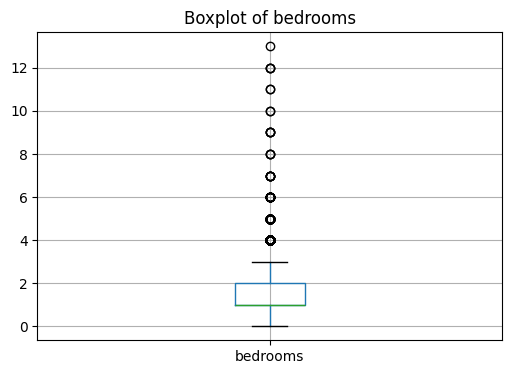

In [8]:
s = listings['bedrooms']
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())

col = 'bedrooms'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

In [9]:
x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers_beds = listings.loc[outlier_mask, [id_col, col]]
print(outliers_beds, len(outliers_beds))

                        id  bedrooms
34                   83045       5.0
40                  106407       4.0
41                  122324       5.0
76                  249512       4.0
188                 674971       5.0
...                    ...       ...
13011  1484630090593155291       4.0
13031  1486770833416145722       4.0
13068  1492703363216625205       4.0
13150  1500193941020865098       4.0
13207  1507099098746638161       4.0

[397 rows x 2 columns] 397


Listings with more than 10 bedrooms were reviewed and appear to reflect genuinely large properties rather than data errors.  
For that reason, these observations are retained and not treated as invalid outliers.

#### Imputing bedrooms

Missing bedroom counts are filled using grouped information from `room_type` and `accommodates`.  
This preserves variation across listing types while using similar properties as reference points.

In [10]:
listings['bedrooms'] = listings.groupby(
    ['room_type', 'accommodates']
)['bedrooms'].transform(lambda x: x.fillna(x.median()))

### Bathrooms

Bathrooms are analysed in the same way as bedrooms: with summary statistics, visualization, and outlier checks.  
This supports a consistent cleaning decision for another key capacity-related variable.

1159 0.08736619930649782
count    12107.000000
mean         1.356984
std          0.702807
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         13.500000
Name: bathrooms, dtype: float64


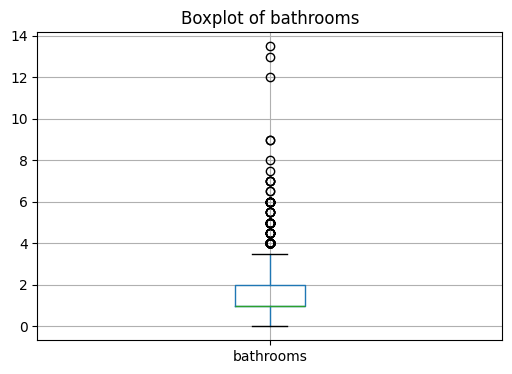

                        id  bathrooms
41                  122324        5.0
76                  249512        4.0
188                 674971        5.5
325                1207304        5.0
340                1261780        4.0
...                    ...        ...
12773  1462473602498877491        6.0
12868  1470887670317858377        7.0
12994  1482464990818085451        4.0
13008  1484073938174359579        5.0
13104  1495535858067851252        4.0

[176 rows x 2 columns] 176


In [11]:
col = 'bathrooms'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())
plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers_bath = listings.loc[outlier_mask, [id_col, col]]
print(outliers_bath, len(outliers_bath))

In [12]:
common_ids = set(outliers_bath['id']) & set(outliers_beds['id'])
print(len(common_ids))

137


The bathroom outliers overlap with the bedroom outliers, which suggests that these listings are simply larger properties.  
They are therefore interpreted as plausible observations rather than clear data issues.

### Imputing bathrooms

Missing bathroom values are filled using the median within groups defined by `room_type` and `accommodates`.  
This mirrors the strategy used for bedrooms and keeps the imputation locally consistent.

In [13]:
listings['bathrooms'] = listings.groupby(
    ['room_type', 'accommodates']
)['bathrooms'].transform(lambda x: x.fillna(x.median()))

### Price formatting

The price column is cleaned and converted from text to numeric format.  
This is necessary before any descriptive analysis or later modeling can be carried out.

In [14]:
listings['price'] = (
    listings['price']
      .str.replace('[\$,]', '', regex=True)  # remove $ and commas
      .astype(float)                         # convert to float
)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\emily\AppData\Local\Temp\ipykernel_21836\234322718.py:3: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True)  # remove $ and commas


### Price distribution

Price is inspected separately because it is both a central variable and a likely target for later analysis.  
Summary statistics and outlier checks are used to better understand the scale and spread of listing prices.

1173 0.08842152872003618
count    12093.000000
mean       268.054908
std        807.323582
min         10.000000
25%        102.000000
50%        142.000000
75%        215.000000
max      18547.000000
Name: price, dtype: float64


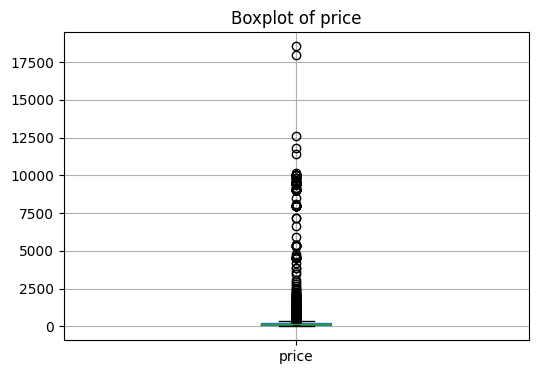

                        id   price
34                   83045   496.0
40                  106407   414.0
76                  249512   964.0
80                  264971   980.0
166                 584756   475.0
...                    ...     ...
13247  1511646524684906450  9000.0
13258  1513710600661172927  8000.0
13263  1514601966798658990  9429.0
13264  1514603753724998674  9429.0
13265  1514605119918326826  9429.0

[1107 rows x 2 columns] 1107


In [15]:
col = 'price'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())

plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers = listings.loc[outlier_mask, [id_col, col]]
print(outliers, len(outliers))

In [16]:
thr = listings['price'].quantile(0.95)  # top 5%
price_outliers = listings[listings['price'] > thr].copy()
cols = ['price', 'accommodates', 'bedrooms', 'beds',
        'review_scores_rating', 'amenities']

price_outliers[cols].describe()

,price,accommodates,bedrooms,beds,review_scores_rating
count,605.000000,605.000000,605.000000,600.000000,462.000000
mean,2239.137190,5.626446,2.393388,3.265000,4.712143
std,2962.720577,3.089605,1.585517,2.328192,0.364865
min,586.000000,1.000000,0.000000,0.000000,2.330000
25%,777.000000,4.000000,1.000000,2.000000,4.592500
50%,980.000000,5.000000,2.000000,3.000000,4.825000
75%,1523.000000,7.000000,3.000000,4.000000,5.000000
max,18547.000000,16.000000,13.000000,17.000000,5.000000


Very high prices appear to be associated with premium or luxury listings rather than obvious errors.  
This raises the question of whether capping extreme prices could improve model stability, but no such change is applied here.

### Handling missing prices

Listings with missing prices are separated from the main dataset.  
Since price is a core variable, imputing it would risk introducing artificial information into later analyses.

In [17]:
no_price = listings[listings['price'].isna()].copy()
listings = listings[listings['price'].notna()].copy()

### Beds

The number of beds is examined with the same summary and outlier procedure used for other numeric housing variables.  
This helps distinguish unusual but valid listings from potential data problems.

26 0.002150004134623336
count    12067.000000
mean         2.232038
std          1.438625
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         17.000000
Name: beds, dtype: float64


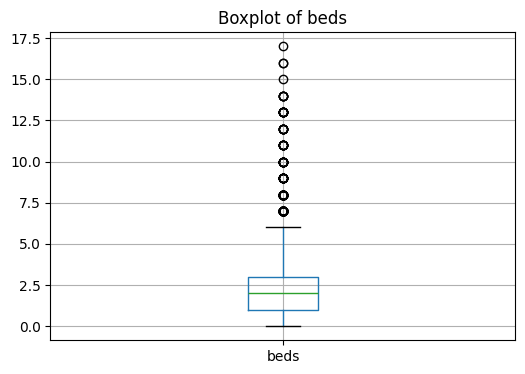

                        id  beds
41                  122324   9.0
48                  141661   7.0
85                  282604   8.0
100                 347062   7.0
170                 611294   8.0
...                    ...   ...
12868  1470887670317858377   7.0
12976  1480486025908852460   8.0
12994  1482464990818085451  12.0
13150  1500193941020865098  11.0
13207  1507099098746638161   8.0

[170 rows x 2 columns] 170


In [18]:
col = 'beds'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())
plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers_nrbed = listings.loc[outlier_mask, [id_col, col]]
print(outliers_nrbed, len(outliers_nrbed))

In [19]:
common_ids = set(outliers_nrbed['id']) & set(outliers_beds['id'])
print(len(common_ids))

113


In [20]:
# ids in outliers_nrbed but not in common_ids
not_common = set(outliers_nrbed['id']) - common_ids
len(not_common)

57

Many bed outliers can be explained by listings with a high number of bedrooms, while others may reflect sofa beds or additional sleeping options outside the bedrooms.  
These values are therefore treated as plausible listing characteristics rather than removed as errors.

### Handling missing beds

Missing values are added based on the average of the number of bedrooms, room type and the number of people the listing accomadetes.

In [21]:
listings['beds'] = listings.groupby(
    ['bedrooms', 'accommodates', 'room_type']
)['beds'].transform(lambda x: x.fillna(x.median()))

### missing reviews

It is difficult to fill missing Values when it comes to reviews because there is not a truly neutral score and filling it with medians or means distorts the data. So a boolean column is added which shows if the review score was missing before. That way if a model is chosen which cannot handle nans, they can be filled with the mean or media review score but they will have the missing note so the model knows that they are not true ratings.

In [22]:
listings['review_scores_missing'] = listings['review_scores_rating'].isna().astype(int)

## Neighbourhood information

Neighbourhood-related columns are inspected to understand how location is represented in the dataset.  
This includes both structured neighbourhood labels and free-text area descriptions.

In [23]:
listings.iloc[10:31][['neighbourhood', 'neighborhood_overview', 'neighbourhood_cleansed']]

,neighbourhood,neighborhood_overview,neighbourhood_cleansed
13,"Florence, Tuscany, Italy",The apartment is located in a very quiet area....,Centro Storico
14,"Florence, Tuscany, Italy",The apartment is two minutes from Piazza Pitti.,Centro Storico
15,"Florence, Tuscany, Italy",Florence is a relatively small city full of pe...,Centro Storico
16,"Florence, Tuscany, Italy",Sant’Ambrogio is one of the oldest districts o...,Centro Storico
17,"Florence, Tuscany, Italy","In few minutes you can reach cool shops, tipic...",Centro Storico
19,"Florence, Tuscany, Italy","San Lorenzo Church, the market and Cappelle Me...",Centro Storico
20,"Florence, Tuscany, Italy",The apartment is strategically located a 10 mi...,Centro Storico
21,"Florence, Tuscany, Italy","San Lorenzo Church, the market and Cappelle Me...",Centro Storico
23,"Florence, Tuscany, Italy",The apartment is located in the part of Floren...,Isolotto Legnaia
24,NaN,NaN,Centro Storico


The neighboorhood column is irrelevant and can be dropped.

In [24]:

listings = listings.drop(['neighbourhood'], axis=1)

## Feature engneering from text columns

The diffrent text columns are used to derive new indicative columns which can be handled better by the model.

### Bathroom text features

The bathroom description field is converted into structured indicators.  
Missing descriptions and terms such as shared, private, or half-bath are encoded as separate features.
Then the bathroom_text column is dropped as it has no use anymore.

In [25]:
listings['bathrooms_text_missing'] = (
    listings['bathrooms'].isna().astype(int)
)

text = listings['bathrooms_text'].fillna('').str.lower()

listings['bath_shared'] = text.str.contains('shared', na=False).astype(int)
listings['bath_private_flag'] = text.str.contains('private', na=False).astype(int)
listings['bath_half'] = text.str.contains('half-bath', na=False).astype(int)

listings = listings.drop(columns=['bathrooms_text'])

### Description-based features


#### Description length

The listing description is first used to derive simple length-based features.  
These variables capture how much information hosts provide in their listing text.

In [26]:
listings['description_missing'] = (
    listings['description'].isna().astype(int)
)

for col in ['description']:
    listings[col + '_len_chars'] = listings[col].str.len().fillna(0)
    listings[col + '_len_words'] = (
        listings[col].fillna('').str.split().str.len()
    )

#### Description keywords

The description text is normalized and searched for selected keywords.  
This creates compact binary features for recurring terms that may reflect style or listing quality.
After extracting the relevant information, the original description column is removed.  
This keeps the dataset more compact and avoids carrying redundant raw text forward.

In [27]:
desc = listings['description'].fillna('').str.lower()

# normalize variants
desc = (
    desc
    .str.replace('luxurious', 'luxury', regex=False)
    .str.replace('cosy', 'cozy', regex=False)
)

# now only use 'luxury' and 'cozy' in your keyword list
keywords = ['luxury', 'modern', 'spacious', 'cozy', 'quiet', 
            'charming', 'bright', 'stylish', 'elegant', 'unforgattable', 'relaxing',
            'everything you need', 'cute', 'comfortable']

for w in keywords:
    col = f'desc_kw_{w}'
    pattern = r'\b' + re.escape(w) + r'\b'
    listings[col] = desc.str.contains(pattern, na=False).astype(int)

listings = listings.drop(columns=['description'])

### Neighbourhood features


#### Overview text features

The free-text neighbourhood overview is converted into simple structural features.  
Missingness and text length are captured to represent how much neighbourhood information a host provides.

In [28]:
listings['neighborhood_overview_missing'] = (
    listings['neighborhood_overview'].isna().astype(int)
)
text_nb = listings['neighborhood_overview'].fillna('').astype(str)

listings['nb_overview_len_chars'] = text_nb.str.len()
listings['nb_overview_len_words'] = text_nb.str.split().str.len()

#### Neighbourhood category indicators

##### Text transformation

The neighbourhood overview text is transformed into binary category features based on keyword groups.  
These indicators summarize whether a listing description emphasizes transport, food, shops, sights, nightlife, greenery, or a quiet residential setting. \
Once the relevant information has been extracted, the original `neighborhood_overview` text is no longer needed.  
The raw column is therefore removed to keep the dataset focused on structured features.

In [29]:
nb = listings['neighborhood_overview'].fillna('').str.lower()

categories = {
    'nb_cat_transport': [
        'bus', 'tram', 'station', 'train station', 'airport',
        'highway', 'exit', 'connected'
    ],
    'nb_cat_food_places': [
        'restaurant', 'restaurants', 'trattoria', 'trattorias',
        'cafe', 'cafes', 'bar', 'bars', 'pastry shop', 'pizzeria'
    ],
    'nb_cat_shops': [
        'shop', 'shops', 'market', 'supermarket',
        'bakery', 'pharmacy', 'laundry', 'bank'
    ],
    'nb_cat_sights': [
        'duomo', 'ponte vecchio', 'uffizi', 'palazzo pitti',
        'boboli', 'piazzale michelangelo', 'santa croce',
        'arno', 'museum', 'basilica', 'church'
    ],
    'nb_cat_nightlife': [
        'pub', 'pubs', 'night club', 'nightlife',
        'lively', 'clubs', 'fun'
    ],
    'nb_cat_greenery': [
        'park', 'garden', 'gardens', 'green', 'greenery', 'river'
    ],
    'nb_cat_quiet_residential': [
        'quiet', 'residential', 'peaceful', 'safe'
    ]
}

for cat, words in categories.items():
    pattern = '|'.join(r'\b' + re.escape(w) + r'\b' for w in words)
    listings[cat] = nb.str.contains(pattern, na=False).astype(int)

listings = listings.drop(columns=['neighborhood_overview'])

### Amenity features

#### Parsing raw amenities

The raw `amenities` field is converted from a string representation into a cleaned Python list.  
This parsing step normalizes formatting, handles parsing errors, and produces lowercase, stripped amenity names in a list for downstream feature engineering.

In [30]:
# If it's a string like: {"Wifi", "Kitchen", "Heating"}
def parse_amenities(x):
    if pd.isna(x):
        return []
    # Replace curly braces with square, so ast.literal_eval can parse
    s = x.replace('{', '[').replace('}', ']')
    try:
        vals = ast.literal_eval(s)
    except Exception:
        return []
    # Normalize: lowercase, strip spaces
    return [a.strip().lower() for a in vals]

listings['amenities_list'] = listings['amenities'].apply(parse_amenities)

#### Amenities exploration

Amenities are highly detailed and often inconsistent in their original form.  
Before feature engineering, the notebook examines the amenity entries to identify recurring patterns and noisy one-off values.

In [31]:
cnt = Counter()
for ams in listings['amenities_list']:
    cnt.update(ams)

amenities_freq = (
    pd.DataFrame.from_dict(cnt, orient='index', columns=['count'])
    .sort_values('count', ascending=False)
)

amenities_freq

,count
hair dryer,11143
wifi,10880
hot water,10680
kitchen,10628
bed linens,9961
...,...
"32 inch hdtv with chromecast, fire tv, standard cable",1
"housekeeping available from 12:30 pm to 4:30 pm, thursday, saturday - available at extra cost",1
"housekeeping available 4 hours a day, every day - available at extra cost",1
"32 inch hdtv with amazon prime video, apple tv, disney+, fire tv, netflix",1


In [32]:
amenity_list = list(amenities_freq.index)

with open("amenities_raw_list.txt", "w", encoding="utf-8") as f:
    for a in amenity_list:
        f.write(a + "\n")

#### Amenity indicators

The raw amenities field is transformed into binary variables for selected listing features.  
This turns a complex text-based column into a structured representation that is easier to analyse.  

In [33]:
INPUT_FILE = "amenities_raw_list.txt"
OUTPUT_FILE = "auto_amenity_categories.json"

PREFIX_WORDS = {"paid", "private", "shared", "free"}

STOPWORDS = {
    "with", "and", "or", "the", "a", "an", "in", "on", "at", "to", "of",
    "for", "by", "from", "available", "upon", "request", "always", "listing",
    "every", "day", "days", "hour", "hours", "pm", "am", "specific", "open",
    "seasonally", "year", "years", "old", "unit", "premises", "property",
    "standard", "other", "extra", "cost"
}

BASE_PATTERNS = [
    ("wifi", ["wifi"]),
    ("tv", ["tv", "hdtv"]),
    ("parking", ["parking", "carport", "garage"]),
    ("pool", ["pool"]),
    ("hot tub", ["hot tub"]),
    ("bbq grill", ["bbq grill"]),
    ("patio or balcony", ["patio", "balcony"]),
    ("backyard", ["backyard"]),
    ("crib", ["crib"]),
    ("high chair", ["high chair"]),
    ("shampoo", ["shampoo"]),
    ("conditioner", ["conditioner"]),
    ("body soap", ["body soap"]),
    ("refrigerator", ["refrigerator", "fridge", "mini fridge", "mini frigo"]),
    ("oven", ["oven"]),
    ("stove", ["stove"]),
    ("microwave", ["microwave"]),
    ("coffee maker", ["coffee maker", "espresso machine", "french press", "keurig", "nespresso", "pour-over"]),
    ("sound system", ["sound system"]),
    ("exercise equipment", ["exercise equipment"]),
    ("fireplace", ["fireplace"]),
    ("washer", ["washer"]),
    ("dryer", ["dryer"]),
    ("kitchen", ["kitchen", "kitchenette"]),
    ("air conditioning", ["air conditioning", "ac", "portable air conditioning", "window ac unit"]),
    ("heating", ["heating"]),
    ("outdoor kitchen", ["outdoor kitchen"]),
    ("sauna", ["sauna"]),
    ("gym", ["gym"]),
    ("housekeeping", ["housekeeping"]),
]

def normalize(text):
    text = text.strip().lower()
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"\s+", " ", text)
    return text

def clean_for_fallback(text):
    text = re.sub(r"\b\d+\b", "", text)
    text = re.sub(r"\b\d+\s*inch\b", "", text)
    text = re.sub(r"\b\d+\s*mbps\b", "", text)
    text = re.sub(r"[^a-z\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def detect_prefix(text):
    for word in PREFIX_WORDS:
        if text.startswith(word + " "):
            return word
    return None

def detect_base_category(text):
    for category, patterns in BASE_PATTERNS:
        for p in patterns:
            if p in text:
                return category
    return None

def fallback_category(text):
    cleaned = clean_for_fallback(text)
    words = [w for w in cleaned.split() if w not in STOPWORDS and len(w) > 2]

    if not words:
        return "misc"

    if len(words) >= 2:
        return " ".join(words[:2])
    return words[0]

def build_category_key(text):
    prefix = detect_prefix(text)
    base = detect_base_category(text)

    if prefix and base:
        return f"{prefix} {base}"
    if prefix and not base:
        tail = fallback_category(text[len(prefix):].strip())
        return f"{prefix} {tail}"
    if base:
        return base
    return fallback_category(text)

def load_amenities(path):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read()

    amenities = [normalize(x) for x in raw.splitlines() if x.strip()]
    return amenities

def auto_group_amenities(path):
    amenities = load_amenities(path)
    grouped = defaultdict(list)

    for amenity in amenities:
        key = build_category_key(amenity)
        grouped[key].append(amenity)

    grouped = dict(sorted(grouped.items(), key=lambda x: (-len(x[1]), x[0])))
    return grouped

grouped_categories = auto_group_amenities(INPUT_FILE)

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(grouped_categories, f, indent=2, ensure_ascii=False)

print(f"Created {len(grouped_categories)} categories and saved them to {OUTPUT_FILE}")

Created 174 categories and saved them to auto_amenity_categories.json


In [34]:
INPUT_JSON = "auto_amenity_categories.json"
OUTPUT_JSON = "reviewed_amenity_categories.json"

with open(INPUT_JSON, "r", encoding="utf-8") as f:
    grouped_categories = json.load(f)

category_names = list(grouped_categories.keys())
current_index = 0

title = widgets.HTML()
count_info = widgets.HTML()
examples_box = widgets.Textarea(
    value="",
    description="Examples:",
    layout=widgets.Layout(width="100%", height="220px")
)

rename_text = widgets.Text(
    value="",
    description="Rename to:",
    layout=widgets.Layout(width="70%")
)

merge_dropdown = widgets.Dropdown(
    options=[],
    description="Merge into:",
    layout=widgets.Layout(width="70%")
)

status = widgets.Output()

btn_prev = widgets.Button(description="Previous", button_style="")
btn_next = widgets.Button(description="Next", button_style="")
btn_rename = widgets.Button(description="Rename", button_style="primary")
btn_merge = widgets.Button(description="Merge", button_style="success")
btn_delete = widgets.Button(description="Delete", button_style="danger")
btn_save = widgets.Button(description="Save JSON", button_style="info")

def refresh_ui():
    global category_names, current_index

    if not category_names:
        title.value = "<h3>No categories left.</h3>"
        count_info.value = ""
        examples_box.value = ""
        rename_text.value = ""
        merge_dropdown.options = []
        return

    current_index = max(0, min(current_index, len(category_names) - 1))
    cat = category_names[current_index]
    items = grouped_categories[cat]

    title.value = f"<h3>Category: {cat}</h3>"
    count_info.value = f"<b>{current_index + 1}</b> / {len(category_names)} categories &nbsp; | &nbsp; <b>{len(items)}</b> amenities"
    examples_box.value = "\n".join(items[:80])
    rename_text.value = cat

    merge_options = [c for c in category_names if c != cat]
    merge_dropdown.options = merge_options if merge_options else []

def show_status(message):
    with status:
        clear_output()
        print(message)

def on_prev(_):
    global current_index
    if current_index > 0:
        current_index -= 1
    refresh_ui()

def on_next(_):
    global current_index
    if current_index < len(category_names) - 1:
        current_index += 1
    refresh_ui()

def on_rename(_):
    global category_names, current_index
    if not category_names:
        return

    old_name = category_names[current_index]
    new_name = rename_text.value.strip().lower()

    if not new_name:
        show_status("Rename failed: new name is empty.")
        return

    if new_name == old_name:
        show_status("Nothing changed.")
        return

    if new_name in grouped_categories:
        grouped_categories[new_name].extend(grouped_categories[old_name])
        del grouped_categories[old_name]
        show_status(f'Merged "{old_name}" into existing category "{new_name}".')
    else:
        grouped_categories[new_name] = grouped_categories.pop(old_name)
        show_status(f'Renamed "{old_name}" to "{new_name}".')

    category_names = list(grouped_categories.keys())
    current_index = min(current_index, len(category_names) - 1)
    refresh_ui()

def on_merge(_):
    global category_names, current_index
    if not category_names:
        return

    source = category_names[current_index]
    target = merge_dropdown.value

    if not target:
        show_status("Merge failed: choose a target category.")
        return

    if source == target:
        show_status("Merge failed: source and target are the same.")
        return

    grouped_categories[target].extend(grouped_categories[source])
    del grouped_categories[source]

    show_status(f'Merged "{source}" into "{target}".')

    category_names = list(grouped_categories.keys())
    current_index = min(current_index, len(category_names) - 1)
    refresh_ui()

def on_delete(_):
    global category_names, current_index
    if not category_names:
        return

    cat = category_names[current_index]
    del grouped_categories[cat]

    show_status(f'Deleted category "{cat}".')

    category_names = list(grouped_categories.keys())
    current_index = min(current_index, max(0, len(category_names) - 1))
    refresh_ui()

def on_save(_):
    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(grouped_categories, f, indent=2, ensure_ascii=False)
    show_status(f"Saved cleaned categories to {OUTPUT_JSON}")

btn_prev.on_click(on_prev)
btn_next.on_click(on_next)
btn_rename.on_click(on_rename)
btn_merge.on_click(on_merge)
btn_delete.on_click(on_delete)
btn_save.on_click(on_save)

refresh_ui()

ui = widgets.VBox([
    title,
    count_info,
    examples_box,
    rename_text,
    merge_dropdown,
    widgets.HBox([btn_prev, btn_next, btn_rename, btn_merge, btn_delete, btn_save]),
    status
])

display(ui)

In [35]:
with open("reviewed_amenity_categories.json", "r", encoding="utf-8") as f:
    categories = json.load(f)   # dict: category_name -> list of strings [file:32]

amenities = listings["amenities"].fillna("").str.lower()

def parse_amenities(text):
    if not text:
        return []
    try:
        vals = ast.literal_eval(text)
        if isinstance(vals, list):
            return [str(x).strip().lower() for x in vals]
    except:
        pass
    return [x.strip().strip('"').strip("'").lower() for x in text.split(",") if x.strip()]

def has_match(text, words, substring_mode=False):
    amenity_list = parse_amenities(text)
    words = [w.strip().lower() for w in words]

    if substring_mode:
        return int(any(
            any(word in amenity for amenity in amenity_list)
            for word in words
        ))
    else:
        return int(any(word in amenity_list for word in words))

# build all new columns in one go
new_cols = {}

for col, words in categories.items():
    substring_mode = "any" in col.lower()
    new_cols[col] = amenities.apply(lambda x: has_match(x, words, substring_mode)).astype(int)

# concat once → no fragmentation warning
new_df = pd.DataFrame(new_cols, index=listings.index)
listings = pd.concat([listings, new_df], axis=1)

#### Engineered amenity features overview

The resulting table below shows the final amenity-related features after transformation.  

In [36]:
new_df

,tv,wifi,body_soap,shampoo,free_housekeeping,paid_housekeeping,stove,oven,conditioner,refrigerator,...,sun_loungers,toaster,wine_cellar,wine_glasses,free_resort_access,host_greets_you,paid_resort_access,outdoor_kitchen_any,private_outdoor_kitchen,shared_outdoor_kitchen
0,1,1,1,1,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,1,0,0,0,0
2,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,1,1,1,0,0,1,0,1,1,...,0,1,0,1,0,1,0,0,0,0
6,1,1,1,1,1,0,1,0,1,1,...,0,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13261,1,1,0,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
13262,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13263,1,1,0,1,0,0,1,1,0,1,...,0,1,0,0,0,0,0,0,0,0
13264,1,1,0,1,0,0,1,1,0,1,...,0,1,0,0,0,0,0,0,0,0


In [37]:
listings['amenities_count'] = listings['amenities_list'].str.len()
listings['amenities_count'].describe()

count    12093.000000
mean        33.741917
std         13.070737
min          0.000000
25%         25.000000
50%         34.000000
75%         43.000000
max         95.000000
Name: amenities_count, dtype: float64

In [38]:
listings = listings.drop(columns=['amenities', 'amenities_list'])

### Location based features

#### Distance from city center and most important sights

- City Center: 43.7793, 11.2463, 
- Cathedral of Santa Maria del Fiore:
43.773173, 11.255613
- Giotto's bell tower:
43.772843, 11.255706
- Baptistery of San Giovanni:
43.773173, 11.255089
- Signoria Square:
43.769763, 11.255563
- Vecchio Palace:
43.769238, 11.255995

In [39]:
CENTER_LAT, CENTER_LON = 43.7793, 11.2463

SIGHTS = {
    "duomo": (43.773173, 11.255613),        # Cathedral of Santa Maria del Fiore
    "campanile": (43.772843, 11.255706),    # Giotto's bell tower
    "baptistery": (43.773173, 11.255089),   # Baptistery of San Giovanni
    "signoria": (43.769763, 11.255563),     # Piazza della Signoria
    "vecchio_palace": (43.769238, 11.255995) # Palazzo Vecchio
}

R = 6371.0  # Earth radius in km

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [40]:
for name, (lat_sight, lon_sight) in SIGHTS.items():
    col = f"dist_{name}_km"
    listings[col] = haversine(
        listings["latitude"],
        listings["longitude"],
        lat_sight,
        lon_sight
    )

# also distance to city center if you want:
listings["dist_center_km"] = haversine(
    listings["latitude"],
    listings["longitude"],
    CENTER_LAT,
    CENTER_LON
)

#### Angle from City Center

In [41]:
dx = listings["longitude"] - CENTER_LON
dy = listings["latitude"] - CENTER_LAT
listings["angle_from_center"] = np.arctan2(dy, dx)

#### Side of the Arno river

Approximate lat for the Arno through the center (you can take a line or threshold; for central Florence, the river runs roughly east-west a bit south of the Duomo).

In [42]:
river_lat_threshold = 43.770  # rough; adjust by inspecting data
listings["south_of_arno"] = (listings["latitude"] < river_lat_threshold).astype(int)

#### Neighborhood / zone features
Use lat/long to create discrete zones. These act like “pseudo-neighborhoods” learned from coordinates when you don’t have rich neighborhood labels.

In [43]:
coords = listings[["latitude", "longitude"]]

inertias = []
ks = range(2, 16)  # for Florence, 2–15 is reasonable

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(coords)
    inertias.append(km.inertia_)

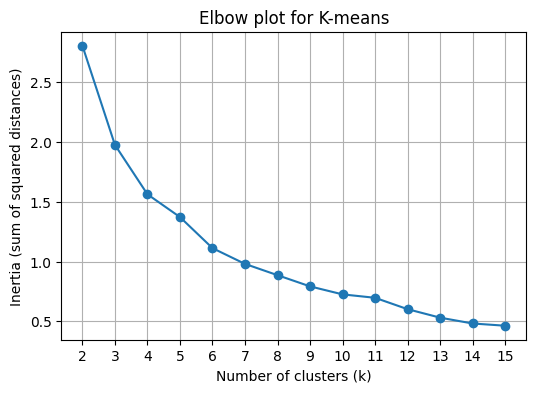

In [44]:
import matplotlib.pyplot as plt

ks = list(range(2, 16))  # or whatever range you used

plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, marker="o")
plt.xticks(ks)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow plot for K-means")
plt.grid(True)
plt.show()

In [45]:
from sklearn.metrics import silhouette_score

candidate_ks = range(4, 12) 
sil_scores = {}

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(coords)
    sil_scores[k] = silhouette_score(coords, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(best_k, sil_scores[best_k])

8 0.3630270687867098


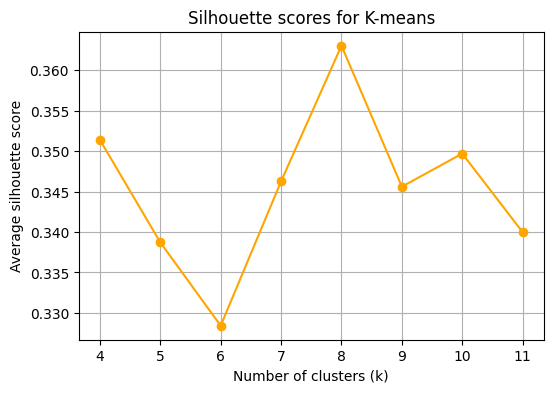

In [46]:
ks_sil = sorted(sil_scores.keys())
scores = [sil_scores[k] for k in ks_sil]

plt.figure(figsize=(6, 4))
plt.plot(ks_sil, scores, marker="o", color="orange")
plt.xticks(ks_sil)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette scores for K-means")
plt.grid(True)
plt.show()

In [47]:
kmeans = KMeans(n_clusters=8, random_state=42)
listings["location_cluster"] = kmeans.fit_predict(coords)

cluster-level median price and average rating

In [51]:
cluster_stats = (
    listings.groupby("location_cluster")
    .agg({
        "price": ["median", "mean", "std"],
        "review_scores_rating": "mean",
        "number_of_reviews": "mean",
        "id": "count"  # or any column to count rows
    })
)

cluster_stats.columns = [
    "cluster_price_median",
    "cluster_price_mean",
    "cluster_price_std",
    "cluster_rating_mean",
    "cluster_reviews_mean",
    "cluster_size"
]
cluster_stats = cluster_stats.reset_index()

listings = listings.merge(cluster_stats, on="location_cluster", how="left")

#### Local Density

In [49]:

coords = listings[["latitude", "longitude"]].to_numpy()

# radius roughly 0.01 degrees ~ 1 km at Florence's latitude
nbrs = NearestNeighbors(radius=0.01)
nbrs.fit(coords)
distances, indices = nbrs.radius_neighbors(coords)

listings["local_density"] = [len(ix) for ix in indices]
listings["log_local_density"] = np.log1p(listings["local_density"])

## Result

At this stage, the dataset has been cleaned and enriched with engineered features derived from text, numeric variables, neighbourhood information, and amenities.  
The resulting table is now in a structured form that can be used for downstream exploratory analysis or predictive modeling.

In [50]:
listings.to_csv("data/listings_features.csv", index=False)